Fix a matrix A. Choose eigenvalues to be all distinct. Find Lambda_A, Q_A

Fix an orientation vector k

Loop through different (small pos. angles theta). Generate K (from k) and hence R = exp(theta K)

Since R = Q_A Q_B^T, form Q_B =Q_A R^T. 

Consider different cases. If Lambda_B are distinct, form B= Q_B Lamba_B Q_B^T

Then look what happens as Lambda_B varies as theta varies.



In [81]:
from time import time
import numpy as np
import os
import sys
from matplotlib import pyplot as plt
from scipy.stats import ortho_group
# include the src path
sys.path.insert(0, "src")
from EigenValueDecomposition import *
from MinMaxthetafromQRQI import *
from SortEigenValues import *
from AnglesSortedQRQI import *
from SplitTensor import *
from Fmeasure import *
from Commeasure import *
import scipy as sci

In [109]:
# Fixed symmetric A
A=np.array([[3,1,0.5],[1,4,0.25],[0.5,0.25,5]])
#A=np.array([[3,1,0.5],[1,3,0.25],[0.5,0.25,5]])

print(A)
LambdaA,QA=np.linalg.eig(A)
print(LambdaA)

# Orientation vector
k =np.array([1,1,1])/np.sqrt(3)
K =np.array([[0,-k[2],k[1]],[k[2],0,-k[0]],[-k[1],k[0],0]])


[[3.   1.   0.5 ]
 [1.   4.   0.25]
 [0.5  0.25 5.  ]]
[2.34812424 4.31020553 5.34167023]


In [110]:
# Fix number of cases to be considered and fix some eigenvalues.
MultR=[1,1,1]
MultI=[1,1,1]
MultRtilde=[1,1,1]

Theta=np.logspace(-3,-1,100)
print(Theta)
N=len(Theta)

N0=np.zeros((3,3))
Rstore=np.zeros((N,9))
Istore=np.zeros((N,9))
Mlist=np.zeros(9, dtype=complex)
TensorArray=np.zeros((N,9),dtype=complex)
Frequencies=np.zeros(N)
URstore=np.zeros((N,3))
UIstore=np.zeros((N,3))
URtildestore=np.zeros((N,3))
QRstore=np.zeros((N,3,3))
QIstore=np.zeros((N,3,3))
QRtildestore=np.zeros((N,3,3))
MultRstore=np.zeros(N)
MultIstore=np.zeros(N)
MultRtildestore=np.zeros(N)


[0.001      0.00104762 0.0010975  0.00114976 0.0012045  0.00126186
 0.00132194 0.00138489 0.00145083 0.00151991 0.00159228 0.0016681
 0.00174753 0.00183074 0.00191791 0.00200923 0.0021049  0.00220513
 0.00231013 0.00242013 0.00253536 0.00265609 0.00278256 0.00291505
 0.00305386 0.00319927 0.0033516  0.00351119 0.00367838 0.00385353
 0.00403702 0.00422924 0.00443062 0.00464159 0.0048626  0.00509414
 0.0053367  0.00559081 0.00585702 0.00613591 0.00642807 0.00673415
 0.0070548  0.00739072 0.00774264 0.00811131 0.00849753 0.00890215
 0.00932603 0.0097701  0.01023531 0.01072267 0.01123324 0.01176812
 0.01232847 0.0129155  0.01353048 0.01417474 0.01484968 0.01555676
 0.01629751 0.01707353 0.0178865  0.01873817 0.01963041 0.02056512
 0.02154435 0.0225702  0.02364489 0.02477076 0.02595024 0.02718588
 0.02848036 0.02983647 0.03125716 0.03274549 0.03430469 0.03593814
 0.03764936 0.03944206 0.04132012 0.04328761 0.04534879 0.0475081
 0.04977024 0.05214008 0.05462277 0.05722368 0.05994843 0.062802

In [111]:



# Choose angles
for n in range(len(Theta)):
    theta =Theta[n]
    R=sci.linalg.expm(theta*K)
    R=R/np.linalg.norm(R)
    print(R)
    print(R@R.T)
    print(np.linalg.norm(R))

    QB=QA@R.T
    # Set LambdaB=LambdaA for now
    LambdaB=LambdaA
    B=QB@np.diag(LambdaB)@QB.T

    
    uR=LambdaA
    VR=QA
    VRtilde=VR
    VI=QB
    uRtilde=uR
    uI=LambdaB
    R=A
    I=B

# Obtain the corresponding R and I
    Rtilde=R+N0
    M=Rtilde+1j*I
    Mlist[0]=M[0,0]
    Mlist[1]=M[0,1]
    Mlist[2]=M[0,2]
    Mlist[3]=M[1,0]
    Mlist[4]=M[1,1]
    Mlist[5]=M[1,2]
    Mlist[6]=M[2,0]
    Mlist[7]=M[2,1]
    Mlist[8]=M[2,2]
    for i in range(9):
        TensorArray[n,i]=Mlist[i]
# We cannot use eig to compute eigenvalues from eig since eigenvalues are placed close together!
    MultRstore[n] = np.max(MultR)
    MultIstore[n] = np.max(MultI)
    MultRtildestore[n] = np.max(MultRtilde)
    for i in range(3):
        URstore[n,i]=uR[i]
        UIstore[n,i]=uI[i]
        URtildestore[n,i]=uRtilde[i]

        for j in range(3):
            QRstore[n,i,j]=VR[i,j]
            QIstore[n,i,j]=VI[i,j]
            QRtildestore[n,i,j]=VRtilde[i,j]
# Frequencies used as dummy array to store angles            
Frequencies=Theta
            
Rstore,Istore,Rtildestore, N0store = SplitTensor(TensorArray,Frequencies,N0)            
            
# Determine eigenvalue decompositions of N0, R, I, Rtilde (no sorting applied), and their multiplicities
MultRstore, MultIstore, MultRtildestore, MultN0store, URstore, UIstore, URtildestore, UN0store, QRstore, QIstore, QRtildestore, QN0store = EigenValueDecomposition(N0,TensorArray,Frequencies)

# Determine the maximal and minimal angles from QR and QI also output d_F metric for these orderings
FixEvecs="Yes"#"Yes"
MinAnglestoreRI, MaxAnglestoreRI, dFMinAnglestoreRI, dFMaxAnglestoreRI,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore = MinMaxthetafromQRQI(Frequencies,QRstore,QIstore,URstore, UIstore,MultRstore,MultIstore,FixEvecs)
SortedMultRstore=[]
SortedMultIstore=[]

# Sort eigenvalues (and eigenvectors) so that || Lambda_R - Lambda_I || is maximal
sorteigenvalues="MaxDifference"
SortedMultRstore, SortedMultIstore, SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore = SortEigenValues(MultRstore, MultIstore, URstore, UIstore, QRstore, QIstore, Frequencies, sorteigenvalues, Rstore, Istore)

# Obtain angles for this sorted min-max combination
AnglestoreRIsortedmaxdiff = AnglesSortedQRQI(SortedQRstore,SortedQIstore,Frequencies)

#Obtain f meauses (approx and exact constant)
AnglestoreRIfmeasfullconstsortedmaxdiff, AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmaxdiff_max, RIfmeasapprx_den_const_max = Fmeasure(sorteigenvalues,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore, Rstore,Istore, Frequencies)

#Obtain Com-meauses (approx and exact constant)
AnglestoreRIcommeasfullconstsortedmaxdiff, AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmaxdiff_max, RIcommeapprx_den_const_max = Commeasure(sorteigenvalues,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore, Rstore,Istore, Frequencies)

# Sort eigenvalues (and eigenvectors) so that || Lambda_R - Lambda_I || is minimal
sorteigenvalues="MinDifference"
SortedMultRstore, SortedMultIstore, SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore = SortEigenValues(MultRstore, MultIstore, URstore, UIstore, QRstore, QIstore, Frequencies, sorteigenvalues, Rstore, Istore)
# Obtain angles for this sorted min-max combination
AnglestoreRIsortedmindiff = AnglesSortedQRQI(SortedQRstore,SortedQIstore,Frequencies)

#Obtain f meauses (approx and exact constant)
AnglestoreRIfmeasfullconstsortedmindiff, AnglestoreRIfmeasapprxconstsortedmindiff_min, AnglestoreRIfmeasapprxconstsortedmindiff_max, RIfmeasapprx_den_const_min = Fmeasure(sorteigenvalues,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore, Rstore,Istore, Frequencies)

#Obtain Com-meauses (approx and exact constant)
AnglestoreRIcommeasfullconstsortedmindiff, AnglestoreRIcommeasapprxconstsortedmindiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_max, RIcommeapprx_den_const_min = Commeasure(sorteigenvalues,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore, Rstore,Istore, Frequencies)


[[ 5.77350077e-01 -3.33237053e-04  3.33429503e-04]
 [ 3.33429503e-04  5.77350077e-01 -3.33237053e-04]
 [-3.33237053e-04  3.33429503e-04  5.77350077e-01]]
[[ 3.33333333e-01  7.34536384e-21  2.71050543e-20]
 [ 7.34536384e-21  3.33333333e-01 -2.71050543e-20]
 [ 2.71050543e-20 -2.71050543e-20  3.33333333e-01]]
1.0
[[ 5.77350058e-01 -3.49099580e-04  3.49310794e-04]
 [ 3.49310794e-04  5.77350058e-01 -3.49099580e-04]
 [-3.49099580e-04  3.49310794e-04  5.77350058e-01]]
[[ 3.33333333e-01  1.73112359e-20 -2.71050543e-20]
 [ 1.73112359e-20  3.33333333e-01 -5.42101086e-20]
 [-2.71050543e-20 -5.42101086e-20  3.33333333e-01]]
1.0
[[ 5.77350037e-01 -3.65716945e-04  3.65948752e-04]
 [ 3.65948752e-04  5.77350037e-01 -3.65716945e-04]
 [-3.65716945e-04  3.65948752e-04  5.77350037e-01]]
[[ 3.33333333e-01 -1.48230766e-21 -2.71050543e-20]
 [-1.48230766e-21  3.33333333e-01  0.00000000e+00]
 [-2.71050543e-20  0.00000000e+00  3.33333333e-01]]
1.0
[[ 5.77350015e-01 -3.83125044e-04  3.83379451e-04]
 [ 3.83379451

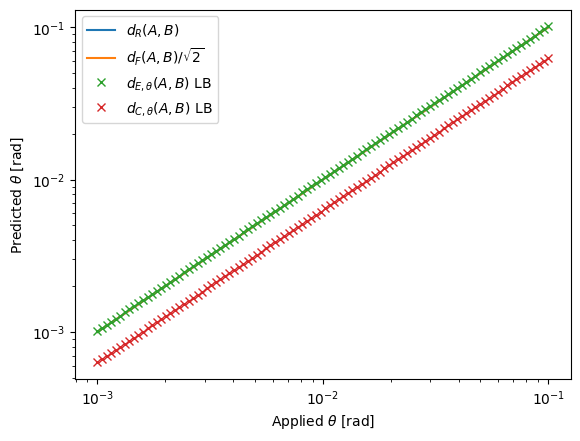

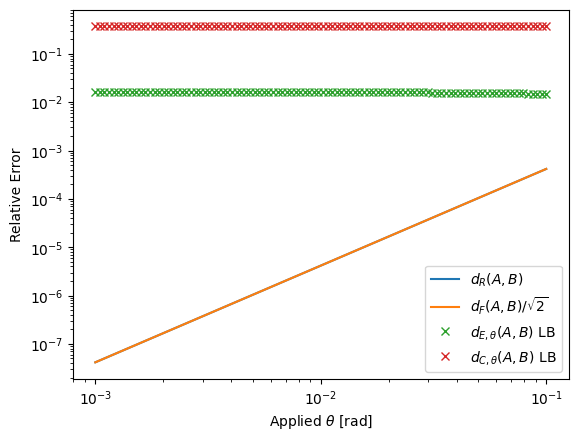

In [112]:
plt.loglog(Frequencies,MinAnglestoreRI,label=r'$d_R(A,B)$')
plt.loglog(Frequencies,dFMinAnglestoreRI/np.sqrt(2),label=r'$d_F(A,B)/\sqrt{2}$')
plt.loglog(Frequencies,np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmindiff_min),'x',label=r'$d_{E,\theta}(A,B)$ LB')
plt.loglog(Frequencies,np.fmin(AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_min),'x',label=r'$d_{C,\theta} (A,B)$ LB')

plt.xlabel(r'Applied $\theta$ [rad]')
plt.ylabel(r'Predicted $\theta$ [rad]')
plt.legend()
plt.show()

plt.loglog(Frequencies,abs(MinAnglestoreRI-Frequencies)/Frequencies,label=r'$d_R(A,B)$')
plt.loglog(Frequencies,abs(dFMinAnglestoreRI/np.sqrt(2)-Frequencies)/Frequencies,label=r'$d_F(A,B)/\sqrt{2}$')
plt.loglog(Frequencies,abs(np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmindiff_min)-Frequencies)/Frequencies,'x',label=r'$d_{E,\theta}(A,B)$ LB')

        #plt.semilogx(Frequencies,np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_max,AnglestoreRIfmeasapprxconstsortedmindiff_min),'x',label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_E({\cal R},{\cal I})$ ')
plt.loglog(Frequencies,abs(np.fmin(AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_min)-Frequencies)/Frequencies,'x',label=r'$d_{C,\theta}(A,B)$ LB')

plt.xlabel(r'Applied $\theta$ [rad]')
plt.ylabel(r'Relative Error')
plt.legend()

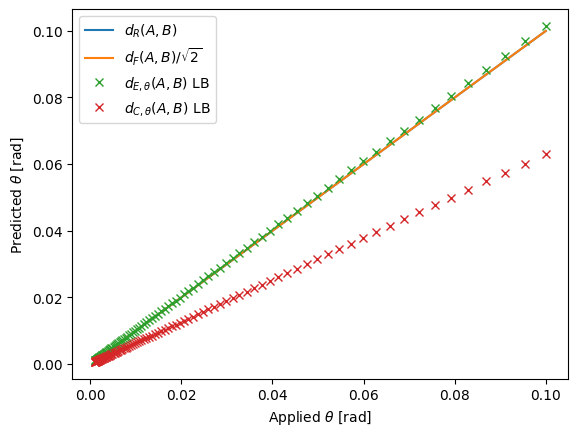

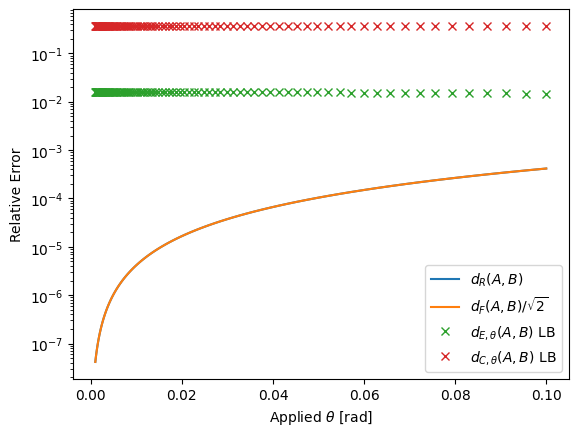

array([0.01597935, 0.01597933, 0.01597932, 0.0159793 , 0.01597929,
       0.01597927, 0.01597925, 0.01597923, 0.0159792 , 0.01597918,
       0.01597915, 0.01597912, 0.01597908, 0.01597904, 0.015979  ,
       0.01597896, 0.01597891, 0.01597885, 0.01597879, 0.01597873,
       0.01597865, 0.01597857, 0.01597849, 0.01597839, 0.01597829,
       0.01597817, 0.01597804, 0.0159779 , 0.01597775, 0.01597758,
       0.0159774 , 0.0159772 , 0.01597698, 0.01597673, 0.01597647,
       0.01597617, 0.01597585, 0.0159755 , 0.01597511, 0.01597469,
       0.01597422, 0.01597371, 0.01597315, 0.01597253, 0.01597186,
       0.01597111, 0.0159703 , 0.01596941, 0.01596842, 0.01596735,
       0.01596617, 0.01596487, 0.01596344, 0.01596188, 0.01596017,
       0.01595829, 0.01595622, 0.01595395, 0.01595147, 0.01594874,
       0.01594574, 0.01594245, 0.01593884, 0.01593488, 0.01593053,
       0.01592576, 0.01592052, 0.01591478, 0.01590847, 0.01590155,
       0.01589395, 0.01588561, 0.01587646, 0.01586642, 0.01585

In [103]:
#print(MinAnglestoreRI,dFMinAnglestoreRI)
#print(np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmindiff_min))
#print(np.fmin(AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_min))

plt.plot(Frequencies,MinAnglestoreRI,label=r'$d_R(A,B)$')
plt.plot(Frequencies,dFMinAnglestoreRI/np.sqrt(2),label=r'$d_F(A,B)/\sqrt{2}$')
plt.plot(Frequencies,np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmindiff_min),'x',label=r'$d_{E,\theta}(A,B)$ LB')
plt.plot(Frequencies,np.fmin(AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_min),'x',label=r'$d_{C,\theta} (A,B)$ LB')

plt.xlabel(r'Applied $\theta$ [rad]')
plt.ylabel(r'Predicted $\theta$ [rad]')
plt.legend()
plt.savefig("check_accurracy_applied_theta_prediction.pdf")
plt.show()

plt.semilogy(Frequencies,abs(MinAnglestoreRI-Frequencies)/Frequencies,label=r'$d_R(A,B)$')
plt.semilogy(Frequencies,abs(dFMinAnglestoreRI/np.sqrt(2)-Frequencies)/Frequencies,label=r'$d_F(A,B)/\sqrt{2}$')
plt.semilogy(Frequencies,abs(np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmindiff_min)-Frequencies)/Frequencies,'x',label=r'$d_{E,\theta}(A,B)$ LB')

        #plt.semilogx(Frequencies,np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_max,AnglestoreRIfmeasapprxconstsortedmindiff_min),'x',label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_E({\cal R},{\cal I})$ ')
plt.semilogy(Frequencies,abs(np.fmin(AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_min)-Frequencies)/Frequencies,'x',label=r'$d_{C,\theta}(A,B)$ LB')

plt.xlabel(r'Applied $\theta$ [rad]')
plt.ylabel(r'Relative Error')
plt.legend()
plt.savefig("check_accurracy_applied_theta_relerror.pdf")
plt.show()

abs(np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmindiff_min)-Frequencies)/Frequencies

In [79]:
def checkeigen(M,u,Q,omega,mytype,tol):
    order=np.argsort(np.abs(u))
    # Order in absolute ascending order
    u=u[order]
    Q=Q[:,order]
    mult=-1*np.ones(3)
    tag=0
    #tol=2e-2#5e-1,1e-1,5e-2,1e-3#5e-2
    #tol=1e-1
    for i in range(3):
        for j in range(i+1,3):
            if np.abs(u[i]-u[j])/np.abs(u[i]) < tol and mult[j]==-1:
                mult[i]=j
                mult[j]=i
                tag=1

    if tag==1:
        print("getting new eigenvectors",mytype,omega)
        #print(u)
        #print(Q)
        for i in range(3):
            if mult[i]==-1:
                break
        # i contains a first non multuple eigenvalue
        u1=u[i]
        if i==0:
            u2=u[1]
            u3=u[2]
        elif i==1:
            u2=u[0]
            u3=u[2]
        else:
            u2=u[0]
            u3=u[1]

        q1=getevectors(M,u1)
        U,V=orthogcomp(q1)
        q2=computeeigen2(q1,U,V,M,u1,u2)
        q3=np.cross(q1,q2)
        #q2,q3=getevectorsclose(q1)
        Q=np.zeros((3,3))
        Q[:,0]=q1[:]
        Q[:,1]=q2[:]
        Q[:,2]=q3[:]
        u=np.array([u1,u2,u3])
        #print(u)
        #print(Q)
        #time.sleep(10)
    return u,Q
#https://www.geometrictools.com/Documentation/RobustEigenSymmetric3x3.pdf
def getevectors(A,eigenvalue):
    Ameigla=A-eigenvalue*np.eye(3)

    r0=Ameigla[0,:]
    r1=Ameigla[1,:]
    r2=Ameigla[2,:]
    r0xr1=np.cross(r0,r1)
    r0xr2=np.cross(r0,r2)
    r1xr2=np.cross(r1,r2)

    d0=np.dot(r0xr1,r0xr1)
    d1=np.dot(r0xr2,r0xr2)
    d2=np.dot(r1xr2,r1xr2)

    dmax=d0
    imax=0
    if d1 > dmax:
        dmax=d1
        imax=1
    if d2 > dmax:
        imax=2
    if imax==0:
        eigenvector=r0xr1/np.sqrt(d0)
    elif imax==1:
        eigenvector=r0xr2/np.sqrt(d1)
    else:
        eigenvector=r1xr2/np.sqrt(d2)
    return eigenvector


# def getevectorsclose(U):
#     if np.abs(U[0]) > np.abs(U[1]):
#         #The component of max abs value is 0 or 2
#         invlength=1/np.sqrt(U[0]*U[0]+U[2]*U[2])
#         V=np.array([-U[2]*invlength,0,U[0]*invlength])
#     else:
#         #The component of max abs value is 1 or 2
#         invlength=1/np.sqrt(U[1]*U[1]+U[2]*U[2])
#         V=np.array([0,U[2]*invlength,-U[1]*invlength])
#     W=np.cross(U,V)
#     return V,W
def orthogcomp(W):
    if np.abs(W[0]) > np.abs(W[1]):
        #The component of max abs value is 0 or 2
        invlength=1/np.sqrt(W[0]*W[0]+W[2]*W[2])
        U=np.array([-W[2]*invlength,0,W[0]*invlength])
    else:
        #The component of max abs value is 1 or 2
        invlength=1/np.sqrt(W[1]*W[1]+W[2]*W[2])
        U=np.array([0,W[2]*invlength,-W[1]*invlength])
    V=np.cross(W,U)
    return U,V

def computeeigen2(eigen0,U,V,A,eig0,eig1):
    AU = A@U
    AV = A@V
    m00=np.dot(U,AU)-eig1
    m01=np.dot(U,AV)-eig1
    m11=np.dot(V,AV)-eig1
    absM00=np.abs(m00)
    absM01=np.abs(m01)
    absM11=np.abs(m11)
    if absM00>= absM11:
        maxAbsComp=np.max([absM00,absM01])
        if maxAbsComp > 0:
            if absM00 >=absM01:
                m01=m01/m00
                m00=1/np.sqrt(1+m01*m01)
                m01=m01*m00
            else:
                m00=m00/m01
                m01=1/np.sqrt(1+m00*m00)
                m00=m00*m01
            eigenvector1=m01*U-m00*V
        else:
            eigenvector1=U
    else:
        maxAbsComp=np.max([absM11,absM01])
        if maxAbsComp > 0:
            if absM11 >=absM01:
                m01 = m01/m11
                m11=1/np.sqrt(1+m01*m01)
                m01=m01*m11
            else:
                m11=m11/m01
                m01=1/np.sqrt(1+m11*m11)
                m11=m11*m01
            eigenvector1=m11*U - m01*V
        else:
            eigenvector1=U
    return eigenvector1

getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new eigenvectors A 0
getting new ei

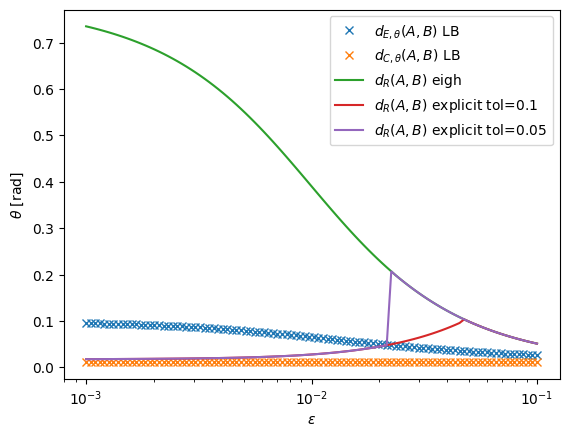

array([0.01212316, 0.0121231 , 0.01212303, 0.01212296, 0.01212289,
       0.0121228 , 0.01212271, 0.01212261, 0.01212249, 0.01212237,
       0.01212224, 0.01212209, 0.01212193, 0.01212175, 0.01212155,
       0.01212134, 0.01212111, 0.01212085, 0.01212057, 0.01212027,
       0.01211993, 0.01211956, 0.01211916, 0.01211872, 0.01211824,
       0.01211772, 0.01211714, 0.01211652, 0.01211583, 0.01211509,
       0.01211427, 0.01211338, 0.01211242, 0.01211137, 0.01211022,
       0.01210898, 0.01210762, 0.01210615, 0.01210456, 0.01210283,
       0.01210096, 0.01209893, 0.01209674, 0.01209438, 0.01209183,
       0.01208908, 0.01208612, 0.01208293, 0.01207951, 0.01207584,
       0.01207191, 0.01206769, 0.01206319, 0.01205837, 0.01205324,
       0.01204776, 0.01204193, 0.01203573, 0.01202914, 0.01202214,
       0.01201472, 0.01200686, 0.01199854, 0.01198975, 0.01198045,
       0.01197063, 0.01196027, 0.01194935, 0.01193785, 0.01192574,
       0.01191299, 0.01189959, 0.01188551, 0.01187072, 0.01185

In [80]:
# Fix an angle theta =0.1 say and loop through different cases of eigenvalues

# Perturbation
TolSwitchVec=[1e-12,1e-1,0.5e-1]
TolSwitchCount=0
for TolSwitch in TolSwitchVec:
    Pert=np.logspace(-3,-1,100)
    for n in range(len(Pert)):
    
        A=np.array([[1-Pert[n],0.01, 0.01],[0.01,1+Pert[n],0.01],[0.01,0.01,2]])
        # QA may be inaccurate
        LambdaA,QA=np.linalg.eigh(A)
        LambdaA,QA=checkeigen(A,LambdaA,QA,0,"A",TolSwitch)

        B=np.diag([1,2,3])#np.array([[3,1,0.5],[1,4,0.25],[0.5,0.25,5]])
        LambdaB,QB=np.linalg.eigh(B)
    
        uR=LambdaA
        VR=QA
        VRtilde=VR
        uRtilde=uR
        uI=LambdaB
        VI=QB
        R=A
        I=B
        N0=np.zeros((3,3))
    # Obtain the corresponding R and I
        Rtilde=R+N0
        M=Rtilde+1j*I
        Mlist[0]=M[0,0]
        Mlist[1]=M[0,1]
        Mlist[2]=M[0,2]
        Mlist[3]=M[1,0]
        Mlist[4]=M[1,1]
        Mlist[5]=M[1,2]
        Mlist[6]=M[2,0]
        Mlist[7]=M[2,1]
        Mlist[8]=M[2,2]
        for i in range(9):
            TensorArray[n,i]=Mlist[i]
# We cannot use eig to compute eigenvalues from eig since eigenvalues are placed close together!
        MultR=[1,1,1]
        MultI=[1,1,1]
        MultRtilde=[1,1,1]
        MultRstore[n] = np.max(MultR)
        MultIstore[n] = np.max(MultI)
        MultRtildestore[n] = np.max(MultRtilde)
        for i in range(3):
            URstore[n,i]=uR[i]
            UIstore[n,i]=uI[i]
            URtildestore[n,i]=uRtilde[i]

            for j in range(3):
                QRstore[n,i,j]=VR[i,j]
                QIstore[n,i,j]=VI[i,j]
                QRtildestore[n,i,j]=VRtilde[i,j]
                Rstore[n,i,j]=R[i,j]
                Istore[n,i,j]=I[i,j]
                Rtildestore[n,i,j]=Rtilde[i,j]
# Frequencies used as dummy array to store angles            
    Frequencies=Pert
            
#Rstore,Istore,Rtildestore, N0store = SplitTensor(TensorArray,Frequencies,N0)            
            
# Determine eigenvalue decompositions of N0, R, I, Rtilde (no sorting applied), and their multiplicities
#MultRstore, MultIstore, MultRtildestore, MultN0store, URstore, UIstore, URtildestore, UN0store, QRstore, QIstore, QRtildestore, QN0store = EigenValueDecomposition(N0,TensorArray,Frequencies)

# Determine the maximal and minimal angles from QR and QI also output d_F metric for these orderings
    FixEvecs="Yes"#"Yes"
    MinAnglestoreRI, MaxAnglestoreRI, dFMinAnglestoreRI, dFMaxAnglestoreRI,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore = MinMaxthetafromQRQI(Frequencies,QRstore,QIstore,URstore, UIstore,MultRstore,MultIstore,FixEvecs)
    SortedMultRstore=[]
    SortedMultIstore=[]

# Sort eigenvalues (and eigenvectors) so that || Lambda_R - Lambda_I || is maximal
    sorteigenvalues="MaxDifference"
    SortedMultRstore, SortedMultIstore, SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore = SortEigenValues(MultRstore, MultIstore, URstore, UIstore, QRstore, QIstore, Frequencies, sorteigenvalues, Rstore, Istore)

# Obtain angles for this sorted min-max combination
    AnglestoreRIsortedmaxdiff = AnglesSortedQRQI(SortedQRstore,SortedQIstore,Frequencies)

#Obtain f meauses (approx and exact constant)
    AnglestoreRIfmeasfullconstsortedmaxdiff, AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmaxdiff_max, RIfmeasapprx_den_const_max = Fmeasure(sorteigenvalues,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore, Rstore,Istore, Frequencies)

#Obtain Com-meauses (approx and exact constant)
    AnglestoreRIcommeasfullconstsortedmaxdiff, AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmaxdiff_max, RIcommeapprx_den_const_max = Commeasure(sorteigenvalues,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore, Rstore,Istore, Frequencies)

# Sort eigenvalues (and eigenvectors) so that || Lambda_R - Lambda_I || is minimal
    sorteigenvalues="MinDifference"
    SortedMultRstore, SortedMultIstore, SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore = SortEigenValues(MultRstore, MultIstore, URstore, UIstore, QRstore, QIstore, Frequencies, sorteigenvalues, Rstore, Istore)
# Obtain angles for this sorted min-max combination
    AnglestoreRIsortedmindiff = AnglesSortedQRQI(SortedQRstore,SortedQIstore,Frequencies)

#Obtain f meauses (approx and exact constant)
    AnglestoreRIfmeasfullconstsortedmindiff, AnglestoreRIfmeasapprxconstsortedmindiff_min, AnglestoreRIfmeasapprxconstsortedmindiff_max, RIfmeasapprx_den_const_min = Fmeasure(sorteigenvalues,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore, Rstore,Istore, Frequencies)

#Obtain Com-meauses (approx and exact constant)
    AnglestoreRIcommeasfullconstsortedmindiff, AnglestoreRIcommeasapprxconstsortedmindiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_max, RIcommeapprx_den_const_min = Commeasure(sorteigenvalues,SortedURstore, SortedUIstore, SortedQRstore, SortedQIstore, SortedKstore, Rstore,Istore, Frequencies)

    if TolSwitchCount==0:
        plt.semilogx(Pert,np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmindiff_min),'x',label=r'$d_{E,\theta}(A,B)$ LB')
        plt.semilogx(Pert,np.fmin(AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_min),'x',label=r'$d_{C,\theta}(A,B)$ LB')
        plt.semilogx(Pert,MinAnglestoreRI,label=r'$d_R(A,B)$ eigh')
    
        #plt.semilogx(Frequencies,np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_max,AnglestoreRIfmeasapprxconstsortedmindiff_min),'x',label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_E({\cal R},{\cal I})$ ')
        
    else:
        plt.semilogx(Pert,MinAnglestoreRI,label=r'$d_R(A,B)$ explicit tol='+str(TolSwitch))
    #plt.plot(Pert,dFMinAnglestoreRI,label=r'$d_F({\cal R},{\cal I})$'+str(TolSwitch))
    TolSwitchCount+=1
plt.xlabel(r'$\epsilon$ ')
plt.ylabel(r'$\theta$ [rad]')
plt.legend()
plt.savefig("check_accurracy_smallpert_theta_predict.pdf")
plt.show()

np.fmin(AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_min)

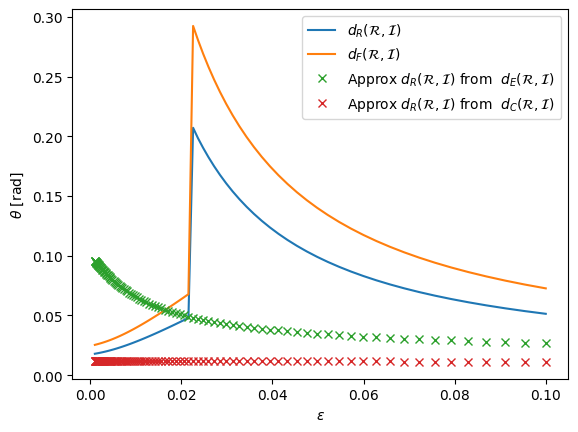

/var/folders/4l/kd3nw5rs03s946hxc6b0d8xc000mpb/T/ipykernel_94823/3220802105.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


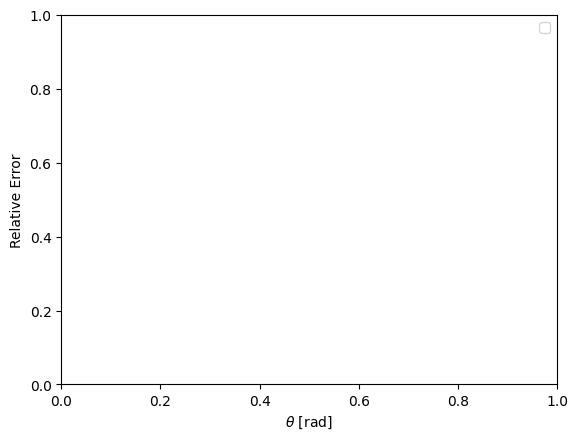

In [33]:
plt.plot(Pert,MinAnglestoreRI,label=r'$d_R({\cal R},{\cal I})$')
plt.plot(Pert,dFMinAnglestoreRI,label=r'$d_F({\cal R},{\cal I})$')
plt.plot(Pert,np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmindiff_min),'x',label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_E({\cal R},{\cal I})$ ')

        #plt.semilogx(Frequencies,np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_max,AnglestoreRIfmeasapprxconstsortedmindiff_min),'x',label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_E({\cal R},{\cal I})$ ')
plt.plot(Pert,np.fmin(AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_min),'x',label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_C({\cal R},{\cal I})$ ')

plt.xlabel(r'$\epsilon$ ')
plt.ylabel(r'$\theta$ [rad]')
plt.legend()
plt.show()

#plt.semilogy(Frequencies,abs(MinAnglestoreRI-ThetaChoice*np.ones(N))/(ThetaChoice*np.ones(N)),label=r'$d_R({\cal R},{\cal I})$')
#plt.semilogy(Frequencies,abs(dFMinAnglestoreRI-ThetaChoice*np.ones(N))/(ThetaChoice*np.ones(N)),label=r'$d_F({\cal R},{\cal I})$')
#plt.semilogy(Frequencies,abs(np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmindiff_min)-ThetaChoice*np.ones(N))/(ThetaChoice*np.ones(N)),label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_E({\cal R},{\cal I})$ ')
#plt.semilogy(Frequencies,abs(np.fmin(AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_min)-ThetaChoice*np.ones(N))/(ThetaChoice*np.ones(N)),label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_C({\cal R},{\cal I})$ ')

#plt.semilogy(Frequencies,abs(MinAnglestoreRI-Frequencies)/Frequencies,label=r'$d_R({\cal R},{\cal I})$')
#plt.semilogy(Frequencies,abs(dFMinAnglestoreRI-Frequencies)/Frequencies,label=r'$d_F({\cal R},{\cal I})$')
#plt.semilogy(Frequencies,abs(np.fmin(AnglestoreRIfmeasapprxconstsortedmaxdiff_min,AnglestoreRIfmeasapprxconstsortedmindiff_min)-Frequencies)/Frequencies,label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_E({\cal R},{\cal I})$ ')
#plt.semilogy(Frequencies,abs(np.fmin(AnglestoreRIcommeasapprxconstsortedmaxdiff_min,AnglestoreRIcommeasapprxconstsortedmindiff_min)-Frequencies)/Frequencies,label=r'Approx $d_R({\cal R},{\cal I})$ from  $d_C({\cal R},{\cal I})$ ')


plt.xlabel(r'$\theta$ [rad]')
plt.ylabel(r'Relative Error')
plt.legend()
plt.show()
